In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Transformations applied on each image
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize the images
])

# Load the dataset
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Define the CNN model
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),  # Input: 1 x 28 x 28, Output: 64 x 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))  # Output: 64 x 14 x 14

        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),  # Output: 64 x 12 x 12
            nn.ReLU(),
            nn.MaxPool2d(2))  # Output: 64 x 6 x 6

        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)  # Flatten the output
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instantiate the model, loss function, and optimizer
model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Function to train the model
def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f'Train Epoch: {epoch} -- Loss: {loss.item():.6f}')

# Training the model
for epoch in range(1, 15):  # Train for 15 epochs
    train(epoch)


# Evaluation
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total}%')

Using device: mps
Train Epoch: 1 -- Loss: 0.493038
Train Epoch: 2 -- Loss: 0.383282
Train Epoch: 3 -- Loss: 0.335266
Train Epoch: 4 -- Loss: 0.329012
Train Epoch: 5 -- Loss: 0.284194
Train Epoch: 6 -- Loss: 0.314874
Train Epoch: 7 -- Loss: 0.284091
Train Epoch: 8 -- Loss: 0.254676
Train Epoch: 9 -- Loss: 0.240069
Train Epoch: 10 -- Loss: 0.258137
Train Epoch: 11 -- Loss: 0.204969
Train Epoch: 12 -- Loss: 0.240029
Train Epoch: 13 -- Loss: 0.215590
Train Epoch: 14 -- Loss: 0.207185
Accuracy of the network on the 10000 test images: 90.84%


In [2]:
from torchsummary import summary
model = FashionCNN()
summary(model, input_size=(1, 28, 28)) # (Channels, Height, Width)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]             640
              ReLU-2           [-1, 64, 28, 28]               0
         MaxPool2d-3           [-1, 64, 14, 14]               0
            Conv2d-4           [-1, 64, 12, 12]          36,928
              ReLU-5           [-1, 64, 12, 12]               0
         MaxPool2d-6             [-1, 64, 6, 6]               0
            Linear-7                  [-1, 128]         295,040
            Linear-8                   [-1, 10]           1,290
Total params: 333,898
Trainable params: 333,898
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 1.02
Params size (MB): 1.27
Estimated Total Size (MB): 2.30
----------------------------------------------------------------


In [3]:
import urllib
import zipfile

url = "https://storage.googleapis.com/learning-datasets/horse-or-human.zip"

file_name = "horse-or-human.zip"
training_dir = 'horse-or-human/training/'
urllib.request.urlretrieve(url, file_name)

zip_ref = zipfile.ZipFile(file_name, 'r')
zip_ref.extractall(training_dir)
zip_ref.close()

url = "https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip"
file_name = "validation-horse-or-human.zip"
validation_dir = 'horse-or-human/validation/'
urllib.request.urlretrieve(url, file_name)

zip_ref = zipfile.ZipFile(file_name, 'r')
zip_ref.extractall(validation_dir)
zip_ref.close()

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the datasets
train_dataset = datasets.ImageFolder(root=training_dir,
                                     transform=transform)
val_dataset = datasets.ImageFolder(root=validation_dir,
                                   transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

class HorsesHumansCNN(nn.Module):
    def __init__(self):
        super(HorsesHumansCNN, self).__init__()
        # using 3 for the input channels as images are RGB
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # Input: 3 x 150 x 150, Output: 16 x 150 x 150
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # Output: 32 x 75 x 75
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Output: 64 x 75 x 75
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 18 * 18, 512) # Adjusted for 150x150 input
        self.drop = nn.Dropout(0.25) # Dropout layer for regularization
        self.fc2 = nn.Linear(512, 1)  # Binary classification
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 18 * 18)
        x = F.relu(self.fc1(x))
        x = self.drop(x)  # Apply dropout
        x = self.fc2(x)
        x = torch.sigmoid(x)  # Use sigmoid to output probabilities
        return x

In [6]:
from torchsummary import summary

model = HorsesHumansCNN()
summary(model, input_size=(3, 150, 150))  # (Channels, Height, Width)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 150, 150]             448
         MaxPool2d-2           [-1, 16, 75, 75]               0
            Conv2d-3           [-1, 32, 75, 75]           4,640
         MaxPool2d-4           [-1, 32, 37, 37]               0
            Conv2d-5           [-1, 64, 37, 37]          18,496
         MaxPool2d-6           [-1, 64, 18, 18]               0
            Linear-7                  [-1, 512]      10,617,344
           Dropout-8                  [-1, 512]               0
            Linear-9                    [-1, 1]             513
Total params: 10,641,441
Trainable params: 10,641,441
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.26
Forward/backward pass size (MB): 5.98
Params size (MB): 40.59
Estimated Total Size (MB): 46.83
-----------------------------------

In [7]:
# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(num_epochs, train_loader=train_loader, val_loader=val_loader):
    model.to(device)
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).float()
            optimizer.zero_grad()
            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_train_loss = running_loss / len(train_loader)
        print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_loader):.4f}')

        # Evaluate on training set
        # model.eval()
        # with torch.no_grad():
        #     correct = 0
        #     total = 0
        #     for images, labels in train_loader:
        #         images, labels = images.to(device), labels.to(device).float()
        #         outputs = model(images).view(-1)
        #         predicted = outputs > 0.5 # Threshold predictions
        #         total += labels.size(0)
        #         correct += (predicted == labels).sum().item()
        #     print(f'Test Set Accuracy: {100 * correct / total:.2f}%')
        
        # Evaluate on validation set
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).float()
                outputs = model(images).view(-1)
                predicted = outputs > 0.5 # Threshold predictions
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                vloss = criterion(outputs, labels)
                val_running_loss += vloss.item()
            print(f'Validation Set Accuracy: {100 * correct / total:.2f}%')
        epoch_val_loss = val_running_loss / len(val_loader)
        
        print(f'Epoch {epoch + 1}, Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')
        
        # append loss of each epoch to the loss tracker
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
    return train_losses, val_losses

    

model_train_loss, model_val_loss = train_model(num_epochs=50)

Epoch 1, Loss: 0.6108
Validation Set Accuracy: 86.33%
Epoch 1, Train Loss: 0.6108 | Val Loss: 0.3780
Epoch 2, Loss: 0.2942
Validation Set Accuracy: 82.03%
Epoch 2, Train Loss: 0.2942 | Val Loss: 0.7525
Epoch 3, Loss: 0.0740
Validation Set Accuracy: 82.03%
Epoch 3, Train Loss: 0.0740 | Val Loss: 1.2017
Epoch 4, Loss: 0.0475
Validation Set Accuracy: 83.59%
Epoch 4, Train Loss: 0.0475 | Val Loss: 1.1664
Epoch 5, Loss: 0.0199
Validation Set Accuracy: 89.06%
Epoch 5, Train Loss: 0.0199 | Val Loss: 1.1265
Epoch 6, Loss: 0.0102
Validation Set Accuracy: 77.34%
Epoch 6, Train Loss: 0.0102 | Val Loss: 5.2840
Epoch 7, Loss: 0.0030
Validation Set Accuracy: 85.94%
Epoch 7, Train Loss: 0.0030 | Val Loss: 3.3317
Epoch 8, Loss: 0.0010
Validation Set Accuracy: 83.59%
Epoch 8, Train Loss: 0.0010 | Val Loss: 5.9769
Epoch 9, Loss: 0.0014
Validation Set Accuracy: 83.20%
Epoch 9, Train Loss: 0.0014 | Val Loss: 6.3337
Epoch 10, Loss: 0.0120
Validation Set Accuracy: 79.30%
Epoch 10, Train Loss: 0.0120 | Val L

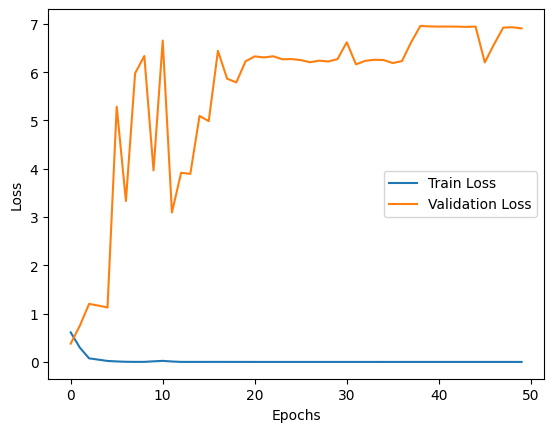

In [8]:
# plot the val loss and train loss
import matplotlib.pyplot as plt
plt.plot(model_train_loss, label='Train Loss')
plt.plot(model_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
def evaluate_model(model):
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model(images).view(-1)
            predicted = outputs > 0.5 # Threshold predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        accuracy = 100 * correct / total
        # print(f'Validation Set Accuracy: {accuracy:.2f}%')
    return accuracy

trained_models = {}
trained_models['baseline'] = {
    'model': model,
    'accuracy': evaluate_model(model),
    'loss': model_train_loss,
    'val_loss': model_val_loss
}
print(f"Baseline model accuracy stored: {trained_models['baseline']['accuracy']:.2f}%")

Baseline model accuracy stored: 85.94%


## Print a sample of the model's predictions wrong and correct

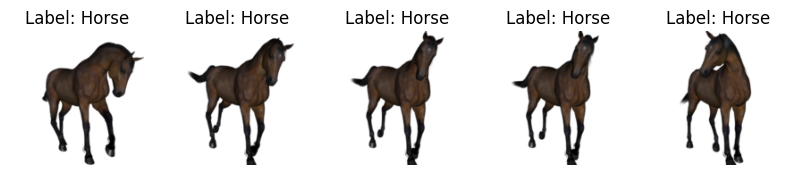

In [10]:
# create a function to print a sample of x amount of images and their labels for the validation set
import matplotlib.pyplot as plt
def print_sample_images(loader, num_images=5):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    
    # Convert to CPU and numpy for plotting
    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].transpose(1, 2, 0) * 0.5 + 0.5)  # Unnormalize
        plt.title('Label: {}'.format('Horse' if labels[i] == 0 else 'Human'))
        plt.axis('off')
    plt.show()

print_sample_images(val_loader, num_images=5)

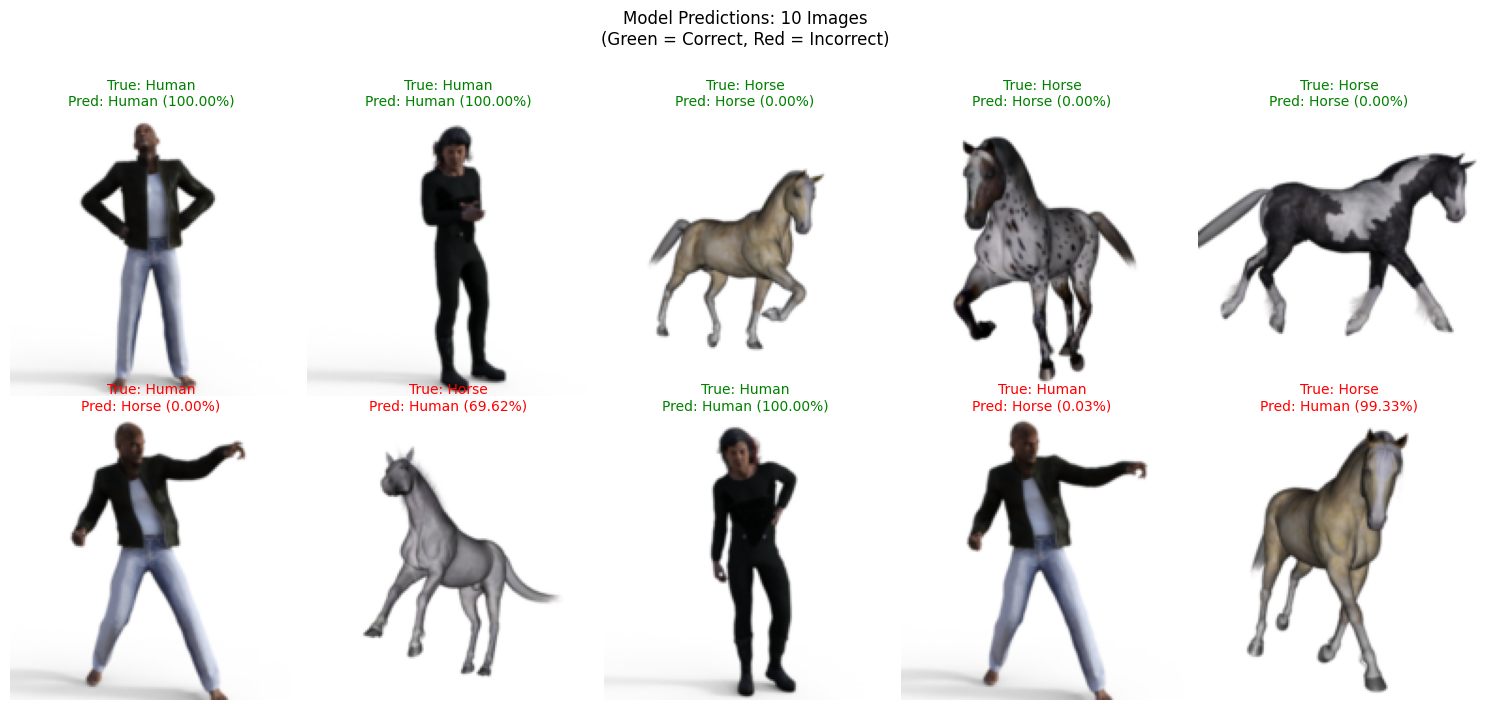


Prediction Summary:
Correct Horses: 94
Correct Humans: 126
Incorrect Horses (predicted as Human): 34
Incorrect Humans (predicted as Horse): 2
Overall Accuracy: 85.94%


In [11]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np

def print_predictions(model, loader, num_images=10):
    """
    Display model predictions showing both correct and incorrect predictions
    evenly split between horses and humans.
    
    Args:
        model: Trained PyTorch model
        loader: DataLoader for validation/test set
        num_images: Total number of images to display (default 10)
    """
    model.eval()
    model.to(device)
    
    # Collect predictions
    correct_horses = []
    correct_humans = []
    incorrect_horses = []
    incorrect_humans = []
    
    with torch.no_grad():
        for images, labels in loader:
            images_device = images.to(device)
            labels_float = labels.float().to(device)
            
            outputs = model(images_device).squeeze()
            predicted = (outputs > 0.5).float()
            
            # Process each image in the batch
            for i in range(len(labels)):
                img = images[i].cpu().numpy()
                true_label = labels[i].item()
                pred_label = predicted[i].cpu().item()
                confidence = outputs[i].cpu().item()
                
                is_correct = (true_label == pred_label)
                
                # Store image info based on true label and correctness
                img_info = (img, true_label, pred_label, confidence)
                
                if true_label == 0:  # Horse
                    if is_correct:
                        correct_horses.append(img_info)
                    else:
                        incorrect_horses.append(img_info)
                else:  # Human
                    if is_correct:
                        correct_humans.append(img_info)
                    else:
                        incorrect_humans.append(img_info)
    
    # Select images to display
    images_per_category = num_images // 4
    remainder = num_images % 4
    
    selected_images = []
    
    # Add images from each category
    categories = [
        (correct_horses, "Correct - Horse"),
        (correct_humans, "Correct - Human"),
        (incorrect_horses, "Incorrect - Should be Horse"),
        (incorrect_humans, "Incorrect - Should be Human")
    ]
    
    for idx, (category_list, category_name) in enumerate(categories):
        # Calculate how many images to take from this category
        n_to_take = images_per_category
        if idx < remainder:
            n_to_take += 1
            
        # Randomly sample from available images
        if len(category_list) >= n_to_take:
            sampled = np.random.choice(len(category_list), n_to_take, replace=False)
            for i in sampled:
                selected_images.append((category_list[i], category_name))
        else:
            # If not enough images in category, take all available
            for img_info in category_list:
                selected_images.append((img_info, category_name))
    
    # Shuffle the selected images for mixed display
    np.random.shuffle(selected_images)
    
    # Display the images
    n_display = len(selected_images)
    if n_display == 0:
        print("No images to display!")
        return
    
    # Calculate grid dimensions
    cols = min(5, n_display)
    rows = (n_display + cols - 1) // cols
    
    plt.figure(figsize=(cols * 3, rows * 3.5))
    
    for idx, ((img, true_label, pred_label, confidence), category) in enumerate(selected_images):
        plt.subplot(rows, cols, idx + 1)
        
        # Unnormalize the image
        img_display = img.transpose(1, 2, 0) * 0.5 + 0.5
        img_display = np.clip(img_display, 0, 1)
        
        plt.imshow(img_display)
        
        # Create title with prediction info
        true_class = "Horse" if true_label == 0 else "Human"
        pred_class = "Horse" if pred_label == 0 else "Human"
        
        # Color code: green for correct, red for incorrect
        color = 'green' if true_label == pred_label else 'red'
        
        title = f'True: {true_class}\nPred: {pred_class} ({confidence:.2%})'
        plt.title(title, color=color, fontsize=10)
        plt.axis('off')
    
    plt.suptitle(f'Model Predictions: {n_display} Images\n(Green = Correct, Red = Incorrect)', 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nPrediction Summary:")
    print(f"Correct Horses: {len(correct_horses)}")
    print(f"Correct Humans: {len(correct_humans)}")
    print(f"Incorrect Horses (predicted as Human): {len(incorrect_horses)}")
    print(f"Incorrect Humans (predicted as Horse): {len(incorrect_humans)}")
    
    total_correct = len(correct_horses) + len(correct_humans)
    total_images = total_correct + len(incorrect_horses) + len(incorrect_humans)
    if total_images > 0:
        accuracy = (total_correct / total_images) * 100
        print(f"Overall Accuracy: {accuracy:.2f}%")

# Call the function to display predictions
print_predictions(model, val_loader, num_images=10)

## Continuing with examples - Image augmentation
Now apply image augmentation to the dataset and train the model again.
Apply:
* Rotation (turning the image)
* Shifting horizontally (moving the pixels horizontally with wrapping)
* Shifting vertically (moving the pixels vertically with wrapping)
* Shearing (slanting the image - moving the pixels either horizontally or vertically but offstetting so that the image would look like a parallelogram)
* Zooming (magnifying a particular region)
* Flipping (vertically or horizontally)

In [12]:
transform_augmented = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomRotation(30),            # Random rotation
    transforms.RandomResizedCrop(150, scale=(0.8, 1.0)),  # Random crop and resize
    transforms.RandomHorizontalFlip(),        # Random horizontal flip
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the datasets with augmentation for training set
train_dataset_augmented = datasets.ImageFolder(root=training_dir,
                                               transform=transform_augmented)
val_dataset_augmented = datasets.ImageFolder(root=validation_dir,
                                             transform=transform)  # Validation set remains unchanged

# DataLoaders
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=32, shuffle=True)
val_loader_augmented = DataLoader(val_dataset_augmented, batch_size=32, shuffle=False)

model = HorsesHumansCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # recreate optimizer for new model
aug_train_loss, aug_val_loss = train_model(num_epochs=50,
                                           train_loader=train_loader_augmented,
                                           val_loader=val_loader_augmented)
trained_models['augmented'] = {
    'model': model,
    'accuracy': evaluate_model(model),
    'loss': aug_train_loss,
    'val_loss': aug_val_loss
}
print(f"Augmented model accuracy stored: {trained_models['augmented']['accuracy']:.2f}%")

Epoch 1, Loss: 0.6990
Validation Set Accuracy: 50.00%
Epoch 1, Train Loss: 0.6990 | Val Loss: 0.7817
Epoch 2, Loss: 0.5274
Validation Set Accuracy: 94.14%
Epoch 2, Train Loss: 0.5274 | Val Loss: 0.3588
Epoch 3, Loss: 0.3492
Validation Set Accuracy: 89.45%
Epoch 3, Train Loss: 0.3492 | Val Loss: 0.2785
Epoch 4, Loss: 0.2000
Validation Set Accuracy: 72.27%
Epoch 4, Train Loss: 0.2000 | Val Loss: 1.1967
Epoch 5, Loss: 0.1648
Validation Set Accuracy: 83.20%
Epoch 5, Train Loss: 0.1648 | Val Loss: 0.6758
Epoch 6, Loss: 0.1122
Validation Set Accuracy: 77.34%
Epoch 6, Train Loss: 0.1122 | Val Loss: 2.3877
Epoch 7, Loss: 0.1064
Validation Set Accuracy: 78.12%
Epoch 7, Train Loss: 0.1064 | Val Loss: 1.4395
Epoch 8, Loss: 0.0924
Validation Set Accuracy: 79.69%
Epoch 8, Train Loss: 0.0924 | Val Loss: 2.1080
Epoch 9, Loss: 0.0780
Validation Set Accuracy: 70.31%
Epoch 9, Train Loss: 0.0780 | Val Loss: 4.6372
Epoch 10, Loss: 0.0700
Validation Set Accuracy: 76.17%
Epoch 10, Train Loss: 0.0700 | Val L

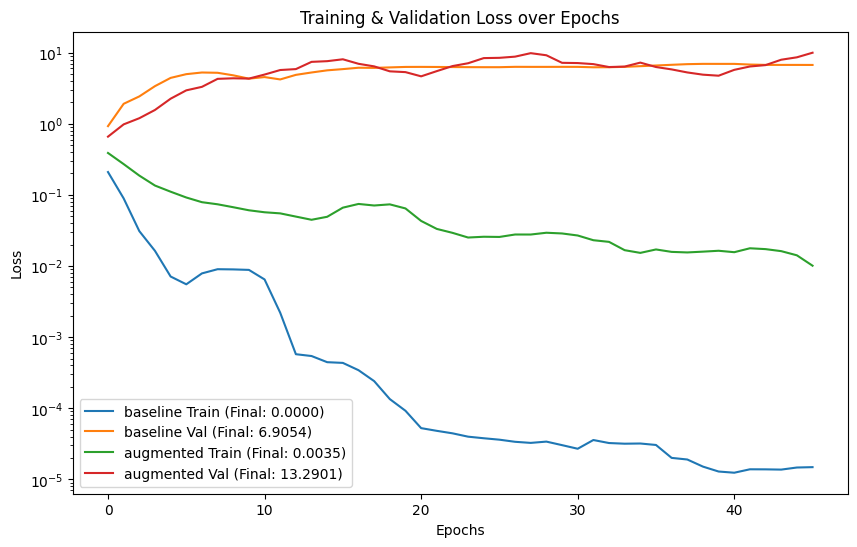

In [13]:
# create a function to plot the loss of multiple models
def plot_multiple_losses(trained_models):
    plt.figure(figsize=(10, 6))
    for name, info in trained_models.items():
        train_loss = info['loss']
        val_loss = info.get('val_loss')
        # Optionally smooth the loss
        smooth = lambda x, w=5: np.convolve(x, np.ones(w)/w, mode='valid')
        plt.plot(smooth(train_loss), label=f'{name} Train (Final: {train_loss[-1]:.4f})')
        if val_loss is not None:
            plt.plot(smooth(val_loss), label=f'{name} Val (Final: {val_loss[-1]:.4f})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss over Epochs')
    plt.legend()
    plt.yscale('log')  # Use log scale if loss drops quickly
    plt.show()
plot_multiple_losses(trained_models)

## Transfer learning

In [22]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch.optim import RMSprop

# Load pretrained Inception V3 model
pre_trained_model = models.inception_v3(pretrained=True, aux_logits=True)

def print_model_summary(model):
    for name, module in model.named_modules():
        print(f"{name} : {module.__class__.__name__}")

print_model_summary(pre_trained_model)

 : Inception3
Conv2d_1a_3x3 : BasicConv2d
Conv2d_1a_3x3.conv : Conv2d
Conv2d_1a_3x3.bn : BatchNorm2d
Conv2d_2a_3x3 : BasicConv2d
Conv2d_2a_3x3.conv : Conv2d
Conv2d_2a_3x3.bn : BatchNorm2d
Conv2d_2b_3x3 : BasicConv2d
Conv2d_2b_3x3.conv : Conv2d
Conv2d_2b_3x3.bn : BatchNorm2d
maxpool1 : MaxPool2d
Conv2d_3b_1x1 : BasicConv2d
Conv2d_3b_1x1.conv : Conv2d
Conv2d_3b_1x1.bn : BatchNorm2d
Conv2d_4a_3x3 : BasicConv2d
Conv2d_4a_3x3.conv : Conv2d
Conv2d_4a_3x3.bn : BatchNorm2d
maxpool2 : MaxPool2d
Mixed_5b : InceptionA
Mixed_5b.branch1x1 : BasicConv2d
Mixed_5b.branch1x1.conv : Conv2d
Mixed_5b.branch1x1.bn : BatchNorm2d
Mixed_5b.branch5x5_1 : BasicConv2d
Mixed_5b.branch5x5_1.conv : Conv2d
Mixed_5b.branch5x5_1.bn : BatchNorm2d
Mixed_5b.branch5x5_2 : BasicConv2d
Mixed_5b.branch5x5_2.conv : Conv2d
Mixed_5b.branch5x5_2.bn : BatchNorm2d
Mixed_5b.branch3x3dbl_1 : BasicConv2d
Mixed_5b.branch3x3dbl_1.conv : Conv2d
Mixed_5b.branch3x3dbl_1.bn : BatchNorm2d
Mixed_5b.branch3x3dbl_2 : BasicConv2d
Mixed_5b.branc

In [23]:
# print a better summary of the model
from torchsummary import summary
summary(pre_trained_model, input_size=(3, 299, 299), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 149, 149]             864
       BatchNorm2d-2         [-1, 32, 149, 149]              64
       BasicConv2d-3         [-1, 32, 149, 149]               0
            Conv2d-4         [-1, 32, 147, 147]           9,216
       BatchNorm2d-5         [-1, 32, 147, 147]              64
       BasicConv2d-6         [-1, 32, 147, 147]               0
            Conv2d-7         [-1, 64, 147, 147]          18,432
       BatchNorm2d-8         [-1, 64, 147, 147]             128
       BasicConv2d-9         [-1, 64, 147, 147]               0
        MaxPool2d-10           [-1, 64, 73, 73]               0
           Conv2d-11           [-1, 80, 73, 73]           5,120
      BatchNorm2d-12           [-1, 80, 73, 73]             160
      BasicConv2d-13           [-1, 80, 73, 73]               0
           Conv2d-14          [-1, 192,

In [24]:
# Freeze all layers up to and including the 'Mixed_7c'
for name, parameter in pre_trained_model.named_parameters():
    parameter.requires_grad = False
    if 'Mixed_7c' in name:
        break

# Modify the existing fully connected layer
num_ftrs = pre_trained_model.fc.in_features
pre_trained_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 1024),  # New fully connected layer with 1024 outputs
    nn.ReLU(),                # Activation layer
    nn.Linear(1024, 2)         # Final layer for binary classification
)

transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize to match Inception V3 input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Load datasets using ImageFolder
train_dataset = ImageFolder(root=training_dir, transform=transform)
val_dataset = ImageFolder(root=validation_dir, transform=transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

def train_model(model, criterion, optimizer, train_loader, num_epochs=10):
    model.train()  # Set the model to training mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(num_epochs):
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            # Handle multiple outputs for training with auxiliary logits
            if isinstance(outputs, tuple):
                output, aux_output = outputs
                loss1 = criterion(output, labels)
                loss2 = criterion(aux_output, labels)
                loss = loss1 + 0.4 * loss2  # Scale the auxiliary loss as is standard for Inception
            else:
                loss = criterion(outputs, labels)

            _, preds = torch.max(output, 1)  # Ensure you use the main output for accuracy calculation

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Update statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects / len(train_loader.dataset)

        print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')



# Only optimize parameters that are set to be trainable
optimizer = RMSprop(filter(lambda p: p.requires_grad, pre_trained_model.parameters()), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train the model
train_model(pre_trained_model, criterion, optimizer, train_loader, num_epochs=3)

Epoch 1/3 - Loss: 4.8249, Acc: 0.9523
Epoch 2/3 - Loss: 3.4426, Acc: 0.9990
Epoch 3/3 - Loss: 3.4380, Acc: 0.9990


In [25]:
# evaluate the model
def evaluate_model(model, val_loader):
    model.eval()  # Set the model to evaluation mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            if isinstance(outputs, tuple):
                output, _ = outputs  # Use only the main output for evaluation
            else:
                output = outputs

            _, preds = torch.max(output, 1)
            running_corrects += torch.sum(preds == labels).item()
            total_samples += labels.size(0)

    accuracy = running_corrects / total_samples
    print(f'Validation Accuracy: {accuracy:.4f}')
    return accuracy

# Evaluate the model
val_accuracy = evaluate_model(pre_trained_model, val_loader)
trained_models['pre_trained_inception'] = {
    'model': pre_trained_model,
    'accuracy': val_accuracy,
    'loss': None,  # Loss not tracked in this case
    'val_loss': None  # Loss not tracked in this case
}
print(f"Pre-trained Inception model accuracy stored: {trained_models['pre_trained_inception']['accuracy']:.2f}%")

Validation Accuracy: 0.9844
Pre-trained Inception model accuracy stored: 0.98%


In [ ]:
def evaluate_model(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    total = 0
    corrects = 0

    with torch.no_grad():  # No need to track gradients for evaluation
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # Handle multiple outputs during evaluation
            if isinstance(outputs, tuple):
                outputs = outputs[0]  # Use only the main output for evaluation

            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    accuracy = corrects / total
    print(f'Accuracy on the validation set: {accuracy:.4f} ({corrects}/{total})')
    return accuracy

# Assuming the necessary imports and pre_trained_model are defined and set up
# Ensure the model and data loaders are on the appropriate device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_trained_model = pre_trained_model.to(device)

# Assuming val_loader is defined and set up as previously shown

accuracy = evaluate_model(pre_trained_model, val_loader, device)

Accuracy on the validation set: 0.9844 (252/256)
